# **MÓDULO 15 - Exercício**
# Análise - Segunda etapa da Pré-Modelagem

Neste notebook vou continuar a atividade da base de **churn de telecomunicação**. A base utilizada aqui já é a versão tratada no módulo anterior, então o foco deste módulo será a parte de **análise univariada, verificação de outliers e análise bivariada com a variável Churn**.

A variável mais importante para essa etapa é `Churn`, pois ela mostra se o cliente abandonou ou não o serviço da empresa.

## 1) Salvando e abrindo a base pré-processada

Primeiro vou carregar a base que foi tratada no módulo anterior e salvar uma cópia em CSV para usar nesta etapa de análise. Esse passo é importante porque deixa a base pronta para continuar a pré-modelagem.

In [1]:
# Importando as principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Configurações visuais básicas
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Carregando a base tratada no módulo anterior
arquivo = 'CHURN_TELECON_MOD08_TAREFA_TRATADO.csv'
df = pd.read_csv(arquivo)

# Salvando uma cópia da base para esta etapa de análise
df.to_csv('CHURN_TELECON_MOD08_TAREFA_ANALISE.csv', index=False)

print('Base carregada com sucesso!')
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')

display(df.head())

Base carregada com sucesso!
Quantidade de linhas: 2495
Quantidade de colunas: 15


,ID_Cliente,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,Streaming_TV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,9237-HQITU,Male,0,No,No,2,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,151.65,Yes


In [2]:
# Conferindo os tipos de dados e se ainda existem valores faltantes
resumo_base = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.astype(str).values,
    'Valores_Nulos': df.isna().sum().values,
    'Percentual_Nulos': (df.isna().mean().values * 100).round(2)
})

resumo_base

,Coluna,Tipo,Valores_Nulos,Percentual_Nulos
0,ID_Cliente,object,0,0.0
1,Genero,object,0,0.0
2,Idoso,int64,0,0.0
3,Casado,object,0,0.0
4,Dependentes,object,0,0.0
5,Tempo_como_Cliente,int64,0,0.0
6,Servico_Internet,object,0,0.0
7,Servico_Seguranca,object,0,0.0
8,Suporte_Tecnico,object,0,0.0
9,Streaming_TV,object,0,0.0


**Insight inicial:**

A base foi carregada com 2.495 clientes e 15 colunas. Como ela já passou pelo pré-processamento no módulo anterior, não encontrei valores nulos nesta versão. As colunas numéricas principais são `Tempo_como_Cliente`, `Pagamento_Mensal` e `Total_Pago`. A coluna `Idoso` também é numérica, mas na prática funciona como uma variável booleana, onde 0 significa que o cliente não é idoso e 1 significa que é idoso.

## 2) Análise univariada

Nesta etapa vou analisar cada variável de forma individual, começando pelo `describe`. A ideia é entender a distribuição geral dos dados antes de olhar a relação com o Churn.

In [3]:
# Describe das variáveis numéricas
analise_numerica = df.describe().T
analise_numerica

,count,mean,std,min,25%,50%,75%,max
Idoso,2495.0,0.161122,0.367717,0.0,0.000,0.00,0.000,1.00
Tempo_como_Cliente,2495.0,32.354309,24.634007,0.0,8.000,29.00,56.000,72.00
Pagamento_Mensal,2495.0,66.356894,28.013627,18.4,45.550,71.45,87.375,118.65
Total_Pago,2495.0,2292.625812,2266.888527,18.8,402.175,1404.65,3874.750,8564.75


In [4]:
# Describe das variáveis categóricas
analise_categorica = df.describe(include='object').T
analise_categorica

,count,unique,top,freq
ID_Cliente,2495,2495,7590-VHVEG,1
Genero,2495,2,Male,1276
Casado,2495,2,No,1266
Dependentes,2495,2,No,1710
Servico_Internet,2495,3,Fiber optic,1124
Servico_Seguranca,2495,3,No,1257
Suporte_Tecnico,2495,3,No,1254
Streaming_TV,2495,3,No,1003
Tipo_Contrato,2495,3,Month-to-month,1373
Metodo_Pagamento,2495,4,Electronic check,832


### 2A) Insights retirados do describe

Pelo `describe`, consegui observar alguns pontos importantes:

- A variável `Tempo_como_Cliente` varia de 0 até 72 meses. A mediana é 29 meses, então metade dos clientes tem até aproximadamente 2 anos e 5 meses de relacionamento com a empresa.
- A variável `Pagamento_Mensal` varia de 18,40 até 118,65. A média ficou em torno de 65, o que mostra que existem clientes com planos mais básicos e outros com planos mais completos.
- A variável `Total_Pago` tem uma amplitude bem maior, indo de 18,80 até 8.564,75. Isso faz sentido, porque o total pago depende tanto do valor mensal quanto do tempo que o cliente ficou na empresa.
- Na variável `Churn`, a classe mais frequente é `No`, ou seja, a maior parte dos clientes da base não abandonou o serviço.
- O tipo de contrato mais comum é `Month-to-month`, que representa contrato mensal. Esse ponto já chama atenção porque contratos mensais normalmente têm menor fidelização.

### 2B) Possíveis outliers pelo describe

Só olhando o `describe`, a variável que mais chama atenção é `Total_Pago`, porque o valor máximo é bem maior que a mediana. Porém, isso não significa automaticamente que seja erro ou outlier, pois clientes antigos naturalmente acumulam valores maiores pagos.

Também observei a variável `Pagamento_Mensal`, mas o valor máximo não parece absurdo para um plano de telecomunicação mais completo. Então, neste primeiro momento, eu vejo **possível assimetria** em `Total_Pago`, mas vou confirmar isso com boxplot e regra do IQR no exercício de outliers.

### 2C) Gráficos para completar a análise univariada

Vou analisar algumas variáveis importantes individualmente: `Churn`, `Tempo_como_Cliente`, `Pagamento_Mensal`, `Tipo_Contrato` e `Servico_Internet`.

In [5]:
# Função simples para gráfico de barras com percentual

def grafico_barras_percentual(serie, titulo, xlabel, ylabel, horizontal=False):
    contagem = serie.value_counts()
    percentual = serie.value_counts(normalize=True).mul(100).round(1)
    tabela = pd.DataFrame({'Quantidade': contagem, 'Percentual': percentual})
    display(tabela)

    fig, ax = plt.subplots(figsize=(10, 5))

    if horizontal:
        ax.barh(contagem.index.astype(str), contagem.values)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.invert_yaxis()
        for i, valor in enumerate(contagem.values):
            ax.text(valor + max(contagem.values) * 0.01, i, f'{percentual.iloc[i]:.1f}%', va='center')
    else:
        ax.bar(contagem.index.astype(str), contagem.values)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        for i, valor in enumerate(contagem.values):
            ax.text(i, valor + max(contagem.values) * 0.01, f'{percentual.iloc[i]:.1f}%', ha='center')

    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

,Quantidade,Percentual
Churn,,
No,1846,74.0
Yes,649,26.0


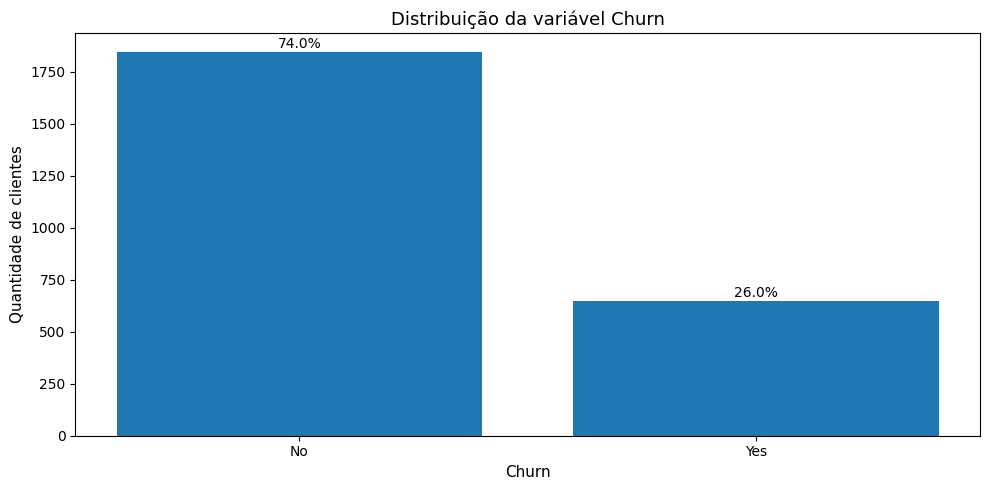

In [6]:
# Distribuição da variável Churn
grafico_barras_percentual(
    df['Churn'],
    'Distribuição da variável Churn',
    'Churn',
    'Quantidade de clientes'
)

**Insight do gráfico de Churn:**

A variável `Churn` está desbalanceada. Aproximadamente 74% dos clientes não abandonaram o serviço, enquanto cerca de 26% abandonaram. Isso é importante para a próxima etapa de modelagem, porque um modelo pode tender a aprender mais a classe majoritária se esse ponto não for considerado.

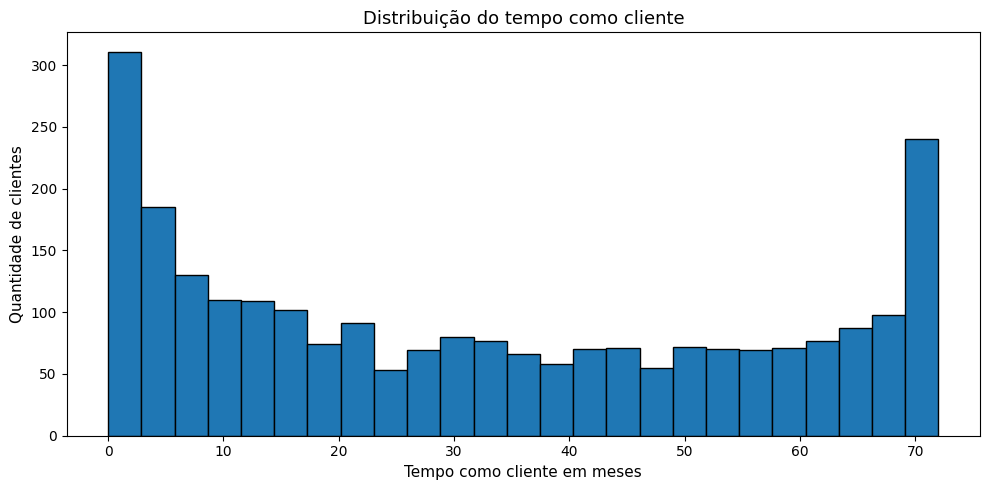

In [7]:
# Distribuição do tempo como cliente
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Tempo_como_Cliente'], bins=25, edgecolor='black')
ax.set_title('Distribuição do tempo como cliente')
ax.set_xlabel('Tempo como cliente em meses')
ax.set_ylabel('Quantidade de clientes')
plt.tight_layout()
plt.show()

**Insight sobre tempo como cliente:**

A distribuição mostra clientes com diferentes tempos de relacionamento. Existe uma concentração de clientes com pouco tempo de empresa, mas também há clientes antigos, chegando a 72 meses. Essa variável pode ser importante porque clientes mais novos podem ter uma chance maior de cancelar o serviço.

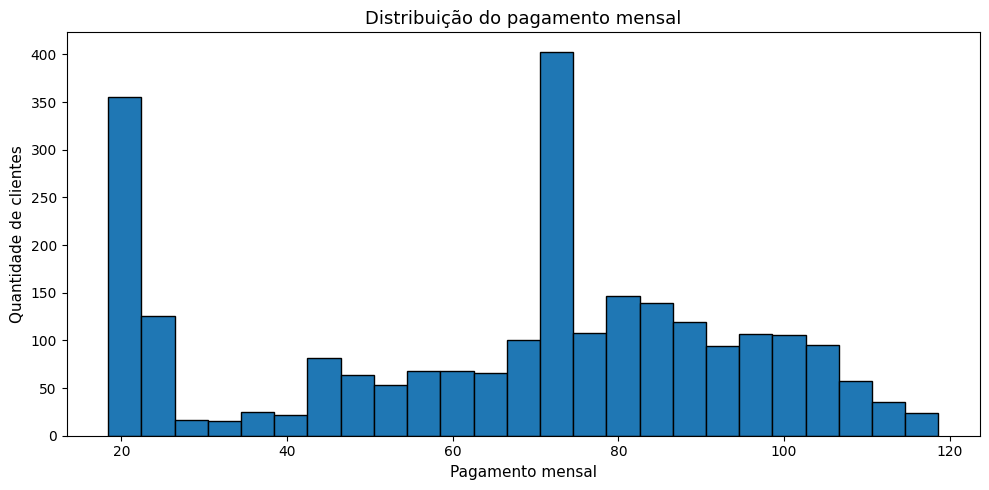

In [8]:
# Distribuição do pagamento mensal
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Pagamento_Mensal'], bins=25, edgecolor='black')
ax.set_title('Distribuição do pagamento mensal')
ax.set_xlabel('Pagamento mensal')
ax.set_ylabel('Quantidade de clientes')
plt.tight_layout()
plt.show()

**Insight sobre pagamento mensal:**

O pagamento mensal tem valores bem distribuídos entre planos mais baratos e planos mais caros. Como existem clientes pagando valores mais altos, essa variável pode ajudar a entender se planos mais caros estão associados a maior cancelamento.

,Quantidade,Percentual
Tipo_Contrato,,
Month-to-month,1373,55.0
Two year,604,24.2
One year,518,20.8


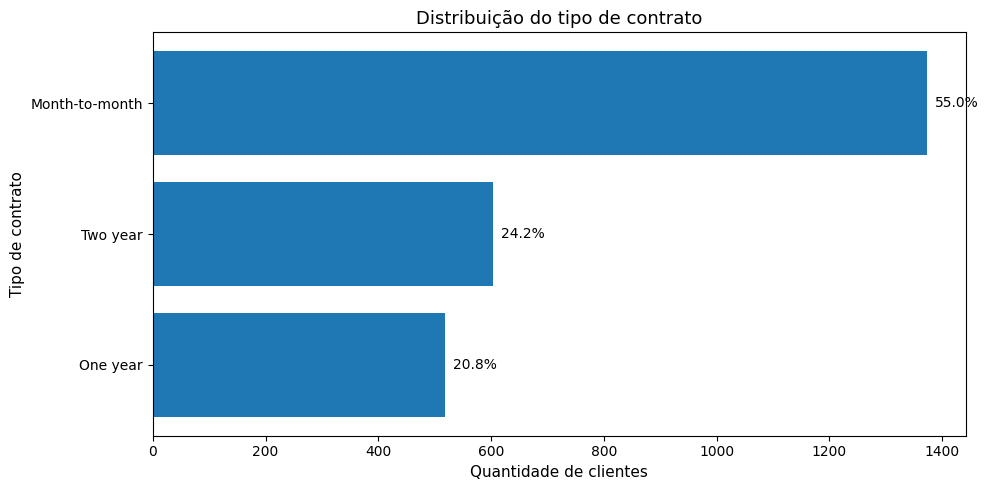

In [9]:
# Distribuição do tipo de contrato
grafico_barras_percentual(
    df['Tipo_Contrato'],
    'Distribuição do tipo de contrato',
    'Quantidade de clientes',
    'Tipo de contrato',
    horizontal=True
)

**Insight sobre tipo de contrato:**

O contrato mensal é o mais frequente na base. Isso é relevante porque contratos mensais geralmente dão mais liberdade para o cliente cancelar, enquanto contratos anuais ou de dois anos costumam indicar maior vínculo com a empresa.

,Quantidade,Percentual
Servico_Internet,,
Fiber optic,1124,45.1
DSL,843,33.8
No,528,21.2


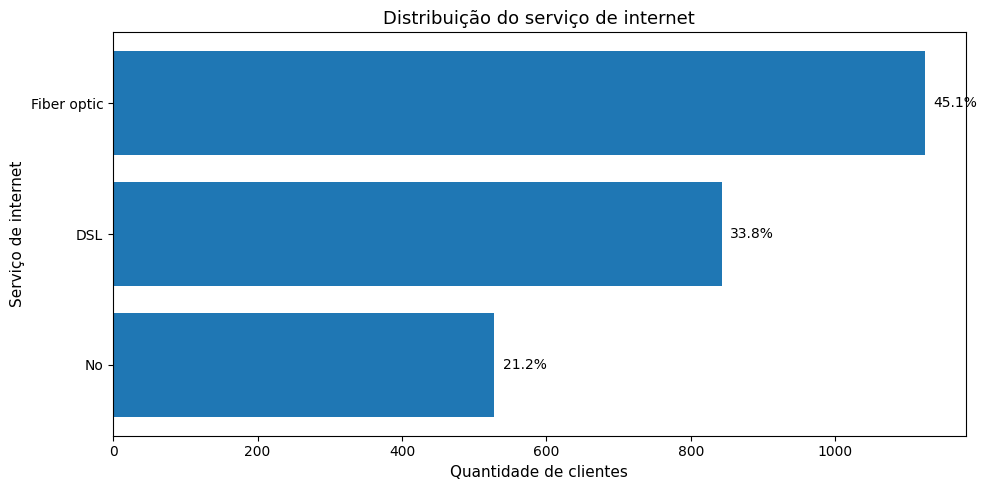

In [10]:
# Distribuição do serviço de internet
grafico_barras_percentual(
    df['Servico_Internet'],
    'Distribuição do serviço de internet',
    'Quantidade de clientes',
    'Serviço de internet',
    horizontal=True
)

**Insight sobre serviço de internet:**

A maior parte dos clientes possui internet por fibra óptica, seguida por DSL. Também existe um grupo de clientes que não possui serviço de internet. Essa variável pode ser importante porque o tipo de internet pode influenciar satisfação, preço e permanência do cliente.

### 2D) Balanceamento das variáveis booleanas

Nesta etapa vou verificar variáveis com duas categorias, como `Genero`, `Idoso`, `Casado`, `Dependentes` e também a variável-alvo `Churn`.


Variável: Genero


,Quantidade,Percentual
Genero,,
Male,1276,51.1
Female,1219,48.9


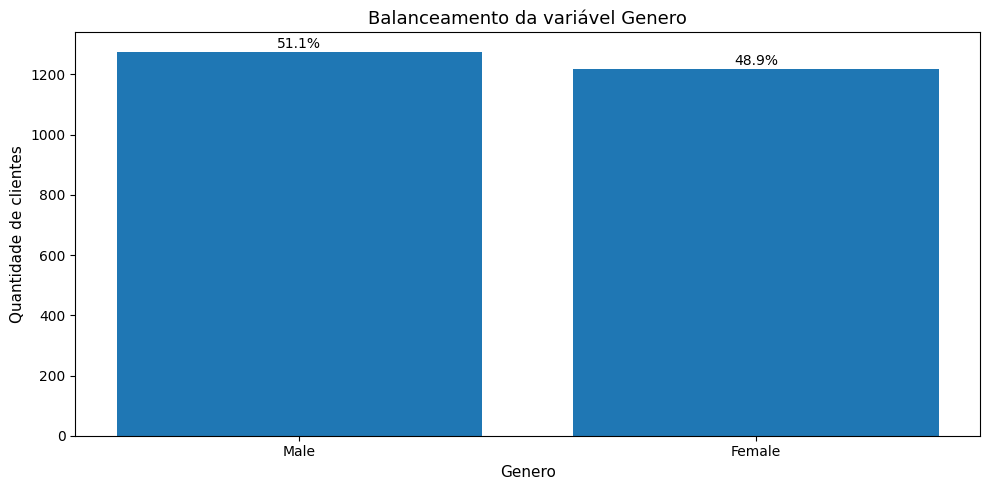


Variável: Idoso


,Quantidade,Percentual
Idoso,,
0,2093,83.9
1,402,16.1


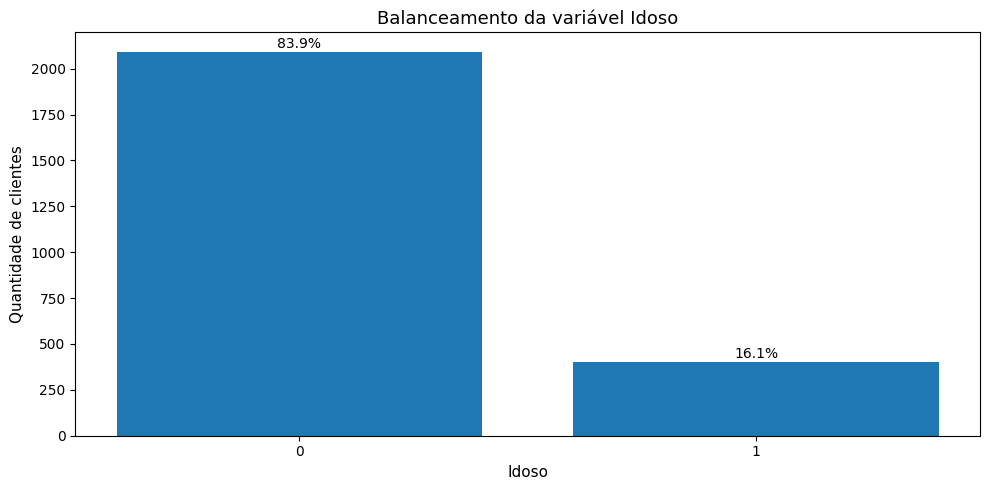


Variável: Casado


,Quantidade,Percentual
Casado,,
No,1266,50.7
Yes,1229,49.3


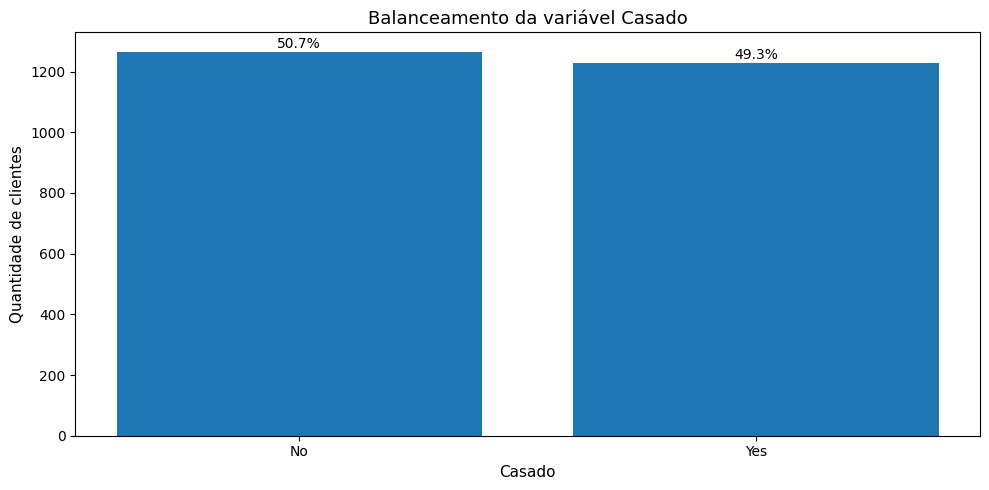


Variável: Dependentes


,Quantidade,Percentual
Dependentes,,
No,1710,68.5
Yes,785,31.5


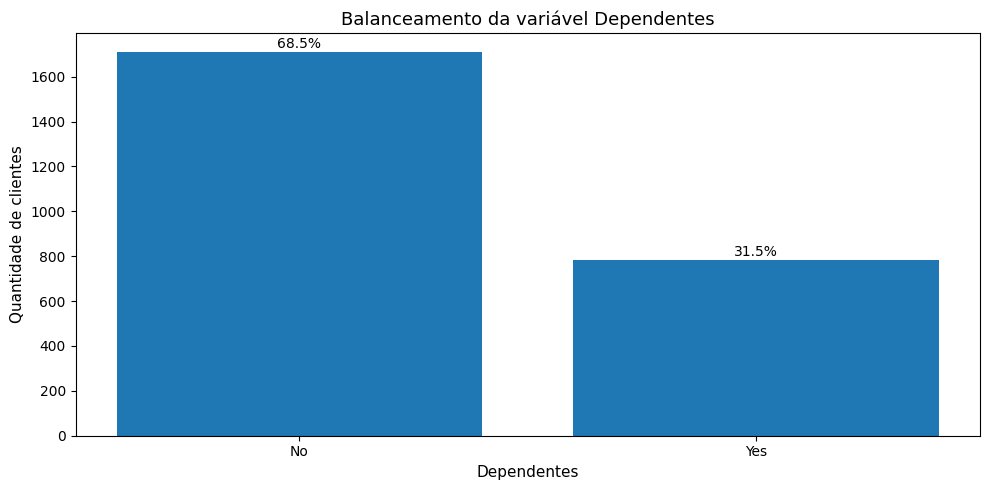


Variável: Churn


,Quantidade,Percentual
Churn,,
No,1846,74.0
Yes,649,26.0


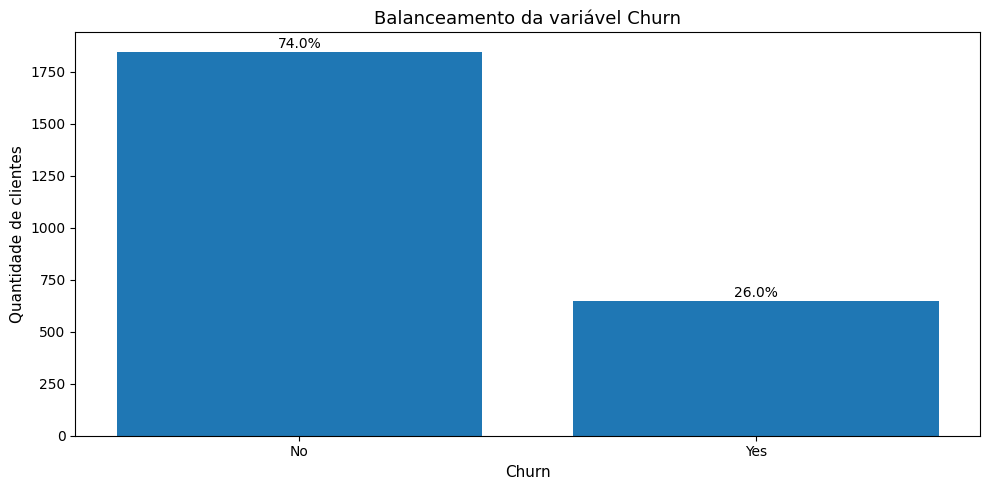

In [11]:
# Verificando o balanceamento das variáveis booleanas/binárias
variaveis_booleanas = ['Genero', 'Idoso', 'Casado', 'Dependentes', 'Churn']

for coluna in variaveis_booleanas:
    print()
    print(f'Variável: {coluna}')
    grafico_barras_percentual(
        df[coluna],
        f'Balanceamento da variável {coluna}',
        coluna,
        'Quantidade de clientes'
    )

**Insights sobre balanceamento:**

- `Genero` está bem balanceado, com proporções próximas entre homens e mulheres.
- `Casado` também está quase balanceado, com proporções próximas entre clientes casados e não casados.
- `Idoso` está desbalanceado, pois a maioria dos clientes não é idosa.
- `Dependentes` também está desbalanceado, com mais clientes sem dependentes.
- `Churn` está desbalanceado, porque a maior parte dos clientes não cancelou. Esse ponto é importante para o futuro modelo preditivo.

## 3) Identificação e tratamento de outliers

Agora vou verificar os outliers das variáveis numéricas usando a regra do IQR. Como `Idoso` é uma variável booleana, não faz sentido tratar outlier nela. Por isso, vou analisar apenas `Tempo_como_Cliente`, `Pagamento_Mensal` e `Total_Pago`.

In [12]:
# Função para calcular limites de outliers pela regra do IQR
variaveis_numericas = ['Tempo_como_Cliente', 'Pagamento_Mensal', 'Total_Pago']

resumo_outliers = []

for coluna in variaveis_numericas:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    qtd_outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)].shape[0]
    percentual_outliers = qtd_outliers / len(df) * 100

    resumo_outliers.append({
        'Variavel': coluna,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Limite_Inferior': limite_inferior,
        'Limite_Superior': limite_superior,
        'Qtd_Outliers': qtd_outliers,
        'Percentual_Outliers': round(percentual_outliers, 2),
        'Minimo': df[coluna].min(),
        'Maximo': df[coluna].max()
    })

resumo_outliers = pd.DataFrame(resumo_outliers)
resumo_outliers

,Variavel,Q1,Q3,IQR,Limite_Inferior,Limite_Superior,Qtd_Outliers,Percentual_Outliers,Minimo,Maximo
0,Tempo_como_Cliente,8.000,56.000,48.000,-64.0000,128.0000,0,0.0,0.0,72.00
1,Pagamento_Mensal,45.550,87.375,41.825,-17.1875,150.1125,0,0.0,18.4,118.65
2,Total_Pago,402.175,3874.750,3472.575,-4806.6875,9083.6125,0,0.0,18.8,8564.75


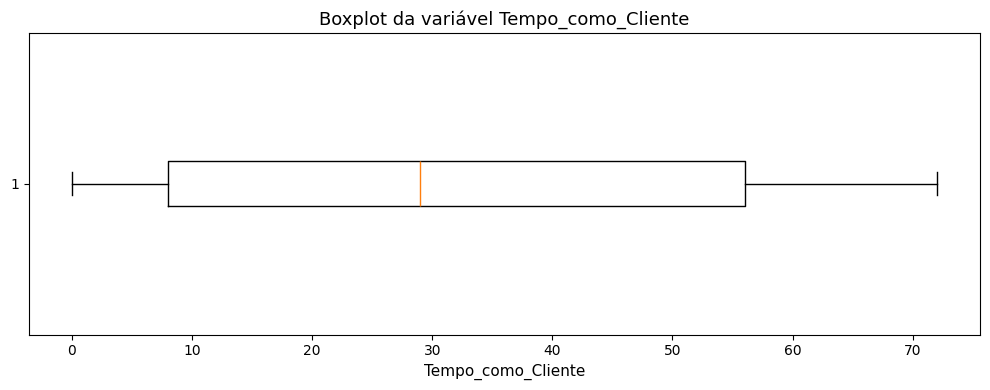

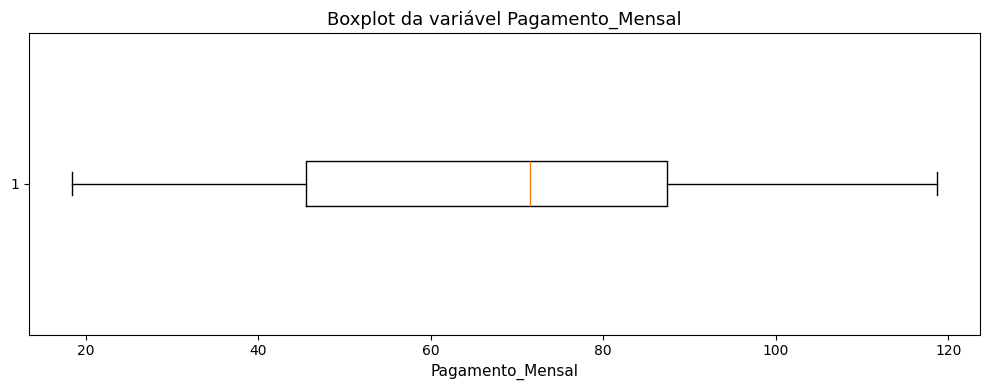

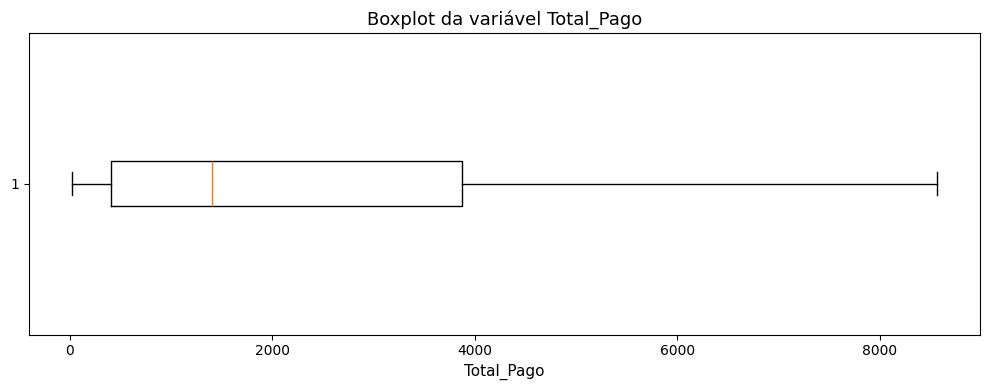

In [13]:
# Boxplots para visualizar as variáveis numéricas
for coluna in variaveis_numericas:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(df[coluna], vert=False)
    ax.set_title(f'Boxplot da variável {coluna}')
    ax.set_xlabel(coluna)
    plt.tight_layout()
    plt.show()

**Decisão sobre os outliers:**

Aplicando a regra do IQR, não foram identificados outliers nas variáveis `Tempo_como_Cliente`, `Pagamento_Mensal` e `Total_Pago`.

Apesar de `Total_Pago` ter valores bem altos em comparação com a mediana, eu optei por **não remover nem alterar esses dados**, porque eles fazem sentido para o negócio. Um cliente que ficou muitos meses na empresa e paga um plano mais caro naturalmente terá um total pago maior. Portanto, esses valores parecem representar comportamento real dos clientes, e não erro de digitação.

Assim, a base foi mantida sem remoção de outliers nesta etapa.

In [14]:
# Mantendo uma cópia da base analisada sem alteração de outliers
# Como não foram encontrados outliers pela regra do IQR, a base final permanece igual.
df_analise = df.copy()

df_analise.to_csv('CHURN_TELECON_MOD08_TAREFA_ANALISE.csv', index=False)

print('Base final para análise salva com sucesso.')
print(df_analise.shape)

Base final para análise salva com sucesso.
(2495, 15)


## 4) Análise bivariada

Nesta etapa vou analisar a relação entre algumas variáveis e o `Churn`. Para isso, separei algumas perguntas que ajudam a entender melhor quais características podem estar associadas ao cancelamento.

In [15]:
# Criando funções para calcular e plotar a taxa de churn por categoria

def taxa_churn_por_categoria(dataframe, coluna):
    tabela_percentual = pd.crosstab(dataframe[coluna], dataframe['Churn'], normalize='index').mul(100).round(2)
    tabela_qtd = pd.crosstab(dataframe[coluna], dataframe['Churn'])

    if 'Yes' not in tabela_percentual.columns:
        tabela_percentual['Yes'] = 0

    resultado = tabela_qtd.join(tabela_percentual[['Yes']].rename(columns={'Yes': 'Taxa_Churn_%'}))
    return resultado.sort_values('Taxa_Churn_%', ascending=False)


def plot_taxa_churn(dataframe, coluna, titulo):
    tabela = taxa_churn_por_categoria(dataframe, coluna).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(tabela[coluna].astype(str), tabela['Taxa_Churn_%'])
    ax.set_title(titulo)
    ax.set_xlabel('Taxa de Churn (%)')
    ax.set_ylabel(coluna)
    ax.invert_yaxis()

    for i, valor in enumerate(tabela['Taxa_Churn_%']):
        ax.text(valor + 0.5, i, f'{valor:.1f}%', va='center')

    plt.tight_layout()
    plt.show()
    display(tabela)

### Pergunta 1: Clientes com menor tempo de contrato cancelam mais?

/tmp/ipykernel_3693/2488648023.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_box, labels=['No', 'Yes'])


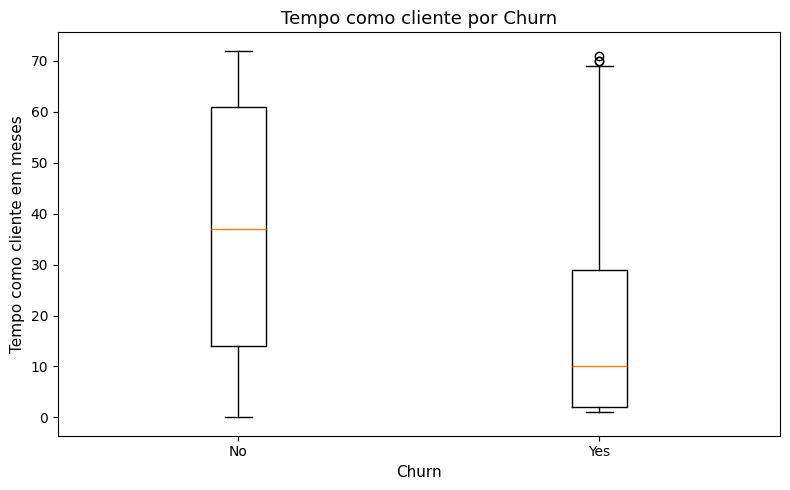

,count,mean,median,min,max
Churn,,,,,
No,1846,37.41,37.0,0,72
Yes,649,17.98,10.0,1,71


In [16]:
# Tempo como cliente em relação ao Churn
dados_box = [
    df_analise.loc[df_analise['Churn'] == valor, 'Tempo_como_Cliente']
    for valor in ['No', 'Yes']
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(dados_box, labels=['No', 'Yes'])
ax.set_title('Tempo como cliente por Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Tempo como cliente em meses')
plt.tight_layout()
plt.show()

df_analise.groupby('Churn')['Tempo_como_Cliente'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

**Insight:**

Sim. Os clientes que cancelaram têm tempo mediano bem menor do que os clientes que permaneceram. Isso indica que o início do relacionamento com a empresa é um período mais sensível e que clientes novos podem precisar de mais acompanhamento para evitar cancelamento.

### Pergunta 2: O tipo de contrato influencia o Churn?

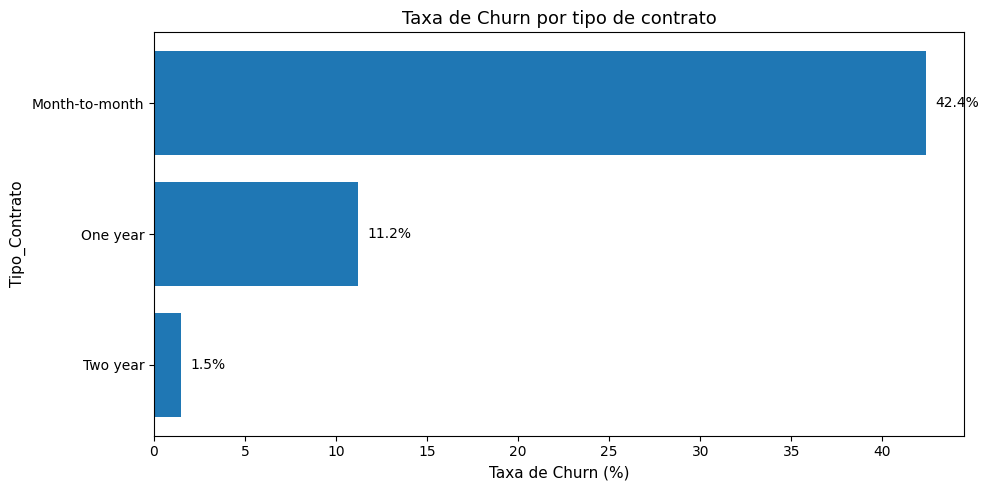

Churn,Tipo_Contrato,No,Yes,Taxa_Churn_%
0,Month-to-month,791,582,42.39
1,One year,460,58,11.20
2,Two year,595,9,1.49


In [17]:
plot_taxa_churn(df_analise, 'Tipo_Contrato', 'Taxa de Churn por tipo de contrato')

**Insight:**

O tipo de contrato tem uma relação muito forte com o Churn. Clientes com contrato mensal (`Month-to-month`) apresentam taxa de cancelamento muito maior. Já clientes com contrato de dois anos têm uma taxa muito baixa de churn. Isso mostra que contratos mais longos ajudam na retenção.

### Pergunta 3: O tipo de serviço de internet está relacionado ao cancelamento?

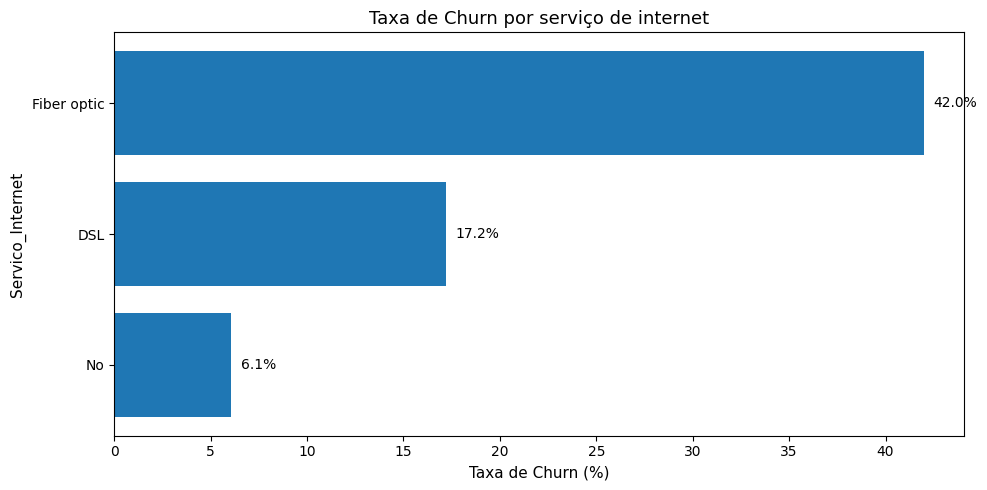

Churn,Servico_Internet,No,Yes,Taxa_Churn_%
0,Fiber optic,652,472,41.99
1,DSL,698,145,17.20
2,No,496,32,6.06


In [18]:
plot_taxa_churn(df_analise, 'Servico_Internet', 'Taxa de Churn por serviço de internet')

**Insight:**

Clientes com fibra óptica possuem a maior taxa de churn. Isso pode indicar que esse serviço tem preço mais alto, maior expectativa de qualidade ou maior concorrência. Já clientes sem serviço de internet têm taxa de churn bem menor.

### Pergunta 4: Ter suporte técnico influencia a permanência do cliente?

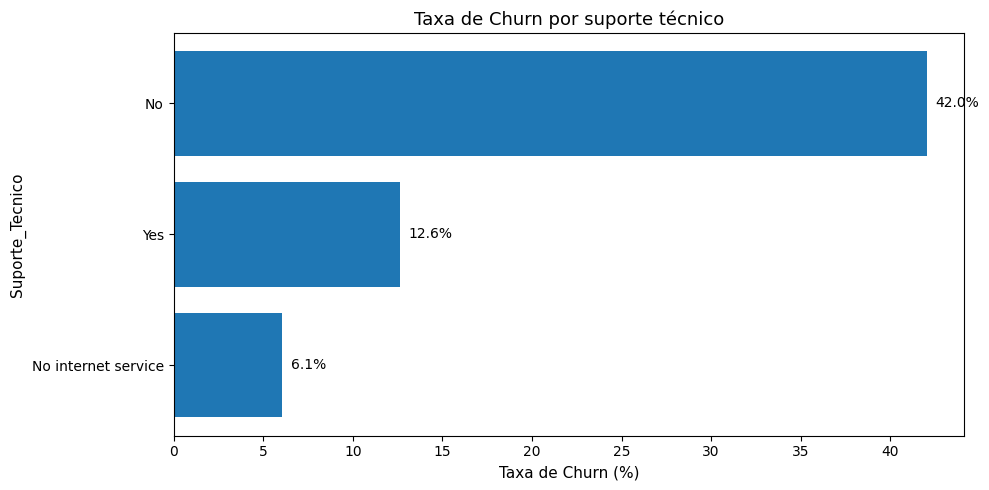

Churn,Suporte_Tecnico,No,Yes,Taxa_Churn_%
0,No,727,527,42.03
1,Yes,623,90,12.62
2,No internet service,496,32,6.06


In [19]:
plot_taxa_churn(df_analise, 'Suporte_Tecnico', 'Taxa de Churn por suporte técnico')

**Insight:**

Clientes sem suporte técnico apresentam taxa de churn bem maior. Na minha interpretação, isso pode indicar que o suporte técnico ajuda na experiência do cliente ou que clientes com suporte contratado estão mais protegidos contra problemas que poderiam levar ao cancelamento.

### Pergunta 5: O método de pagamento tem relação com o Churn?

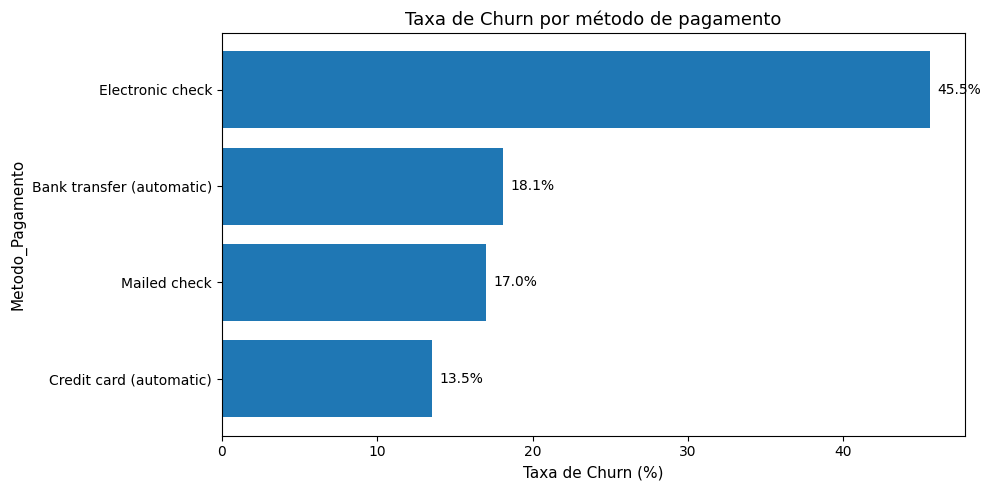

Churn,Metodo_Pagamento,No,Yes,Taxa_Churn_%
0,Electronic check,453,379,45.55
1,Bank transfer (automatic),475,105,18.10
2,Mailed check,439,90,17.01
3,Credit card (automatic),479,75,13.54


In [20]:
plot_taxa_churn(df_analise, 'Metodo_Pagamento', 'Taxa de Churn por método de pagamento')

**Insight:**

O método `Electronic check` apresenta a maior taxa de churn. Já os métodos automáticos, como cartão de crédito e transferência bancária automática, têm taxas menores. Isso pode indicar que pagamentos automáticos ajudam a manter o cliente ativo por mais tempo.

### Pergunta 6: Clientes com Churn pagam mensalidades maiores?

/tmp/ipykernel_3693/272609048.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_box, labels=['No', 'Yes'])


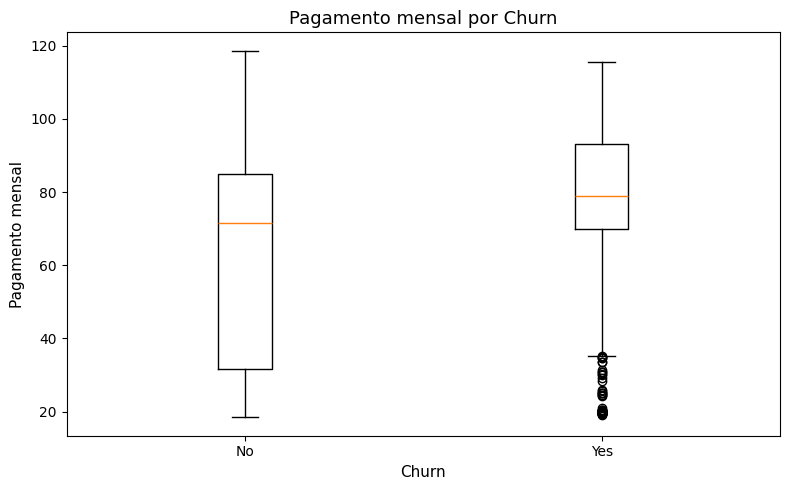

,count,mean,median,min,max
Churn,,,,,
No,1846,62.99,71.45,18.4,118.65
Yes,649,75.94,79.00,19.0,115.55


In [21]:
# Pagamento mensal em relação ao Churn
dados_box = [
    df_analise.loc[df_analise['Churn'] == valor, 'Pagamento_Mensal']
    for valor in ['No', 'Yes']
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(dados_box, labels=['No', 'Yes'])
ax.set_title('Pagamento mensal por Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Pagamento mensal')
plt.tight_layout()
plt.show()

df_analise.groupby('Churn')['Pagamento_Mensal'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

**Insight:**

Os clientes que cancelaram possuem pagamento mensal médio maior do que os clientes que não cancelaram. Isso sugere que preço pode ser um fator importante para o churn, principalmente quando combinado com contrato mensal ou serviço de fibra óptica.

### Pergunta 7: Clientes com dependentes cancelam menos?

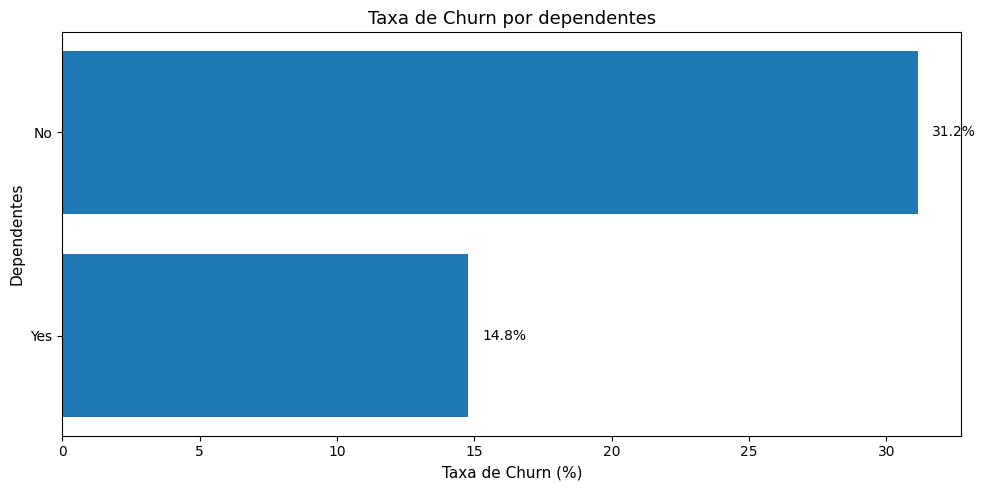

Churn,Dependentes,No,Yes,Taxa_Churn_%
0,No,1177,533,31.17
1,Yes,669,116,14.78


In [22]:
plot_taxa_churn(df_analise, 'Dependentes', 'Taxa de Churn por dependentes')

**Insight:**

Clientes sem dependentes apresentam taxa de churn maior. Isso pode estar relacionado ao perfil de consumo: clientes com dependentes talvez tenham maior necessidade de manter serviços de telecomunicação ativos em casa.

### 4B) Variáveis mais importantes relacionadas ao Churn

Com base na análise bivariada, as variáveis que eu acredito serem mais importantes para o projeto são:

1. `Tipo_Contrato`: foi uma das variáveis com maior diferença na taxa de churn. Contratos mensais cancelam muito mais.
2. `Tempo_como_Cliente`: clientes que cancelaram tinham, em geral, menos tempo de relacionamento com a empresa.
3. `Servico_Internet`: clientes com fibra óptica tiveram maior taxa de cancelamento.
4. `Suporte_Tecnico`: clientes sem suporte técnico cancelaram mais.
5. `Metodo_Pagamento`: clientes com pagamento por electronic check tiveram maior churn.
6. `Pagamento_Mensal`: clientes que cancelaram apresentaram mensalidade média mais alta.

Essas variáveis parecem boas candidatas para uma futura etapa de modelagem, porque mostram diferenças claras entre clientes que cancelaram e clientes que permaneceram.

In [23]:
# Resumo final das principais taxas de churn por variável categórica
variaveis_categoricas_importantes = [
    'Tipo_Contrato',
    'Servico_Internet',
    'Suporte_Tecnico',
    'Metodo_Pagamento',
    'Dependentes',
    'Idoso'
]

for coluna in variaveis_categoricas_importantes:
    print()
    print(f'Taxa de churn por {coluna}')
    display(taxa_churn_por_categoria(df_analise, coluna))


Taxa de churn por Tipo_Contrato


Churn,No,Yes,Taxa_Churn_%
Tipo_Contrato,,,
Month-to-month,791,582,42.39
One year,460,58,11.20
Two year,595,9,1.49



Taxa de churn por Servico_Internet


Churn,No,Yes,Taxa_Churn_%
Servico_Internet,,,
Fiber optic,652,472,41.99
DSL,698,145,17.20
No,496,32,6.06



Taxa de churn por Suporte_Tecnico


...

Churn,No,Yes,Taxa_Churn_%
Metodo_Pagamento,,,
Electronic check,453,379,45.55
Bank transfer (automatic),475,105,18.10
Mailed check,439,90,17.01
Credit card (automatic),479,75,13.54



Taxa de churn por Dependentes


Churn,No,Yes,Taxa_Churn_%
Dependentes,,,
No,1177,533,31.17
Yes,669,116,14.78



Taxa de churn por Idoso


Churn,No,Yes,Taxa_Churn_%
Idoso,,,
1,246,156,38.81
0,1600,493,23.55


## Conclusão geral

Nesta etapa de análise, eu consegui entender melhor o comportamento da base antes da modelagem. A base está sem valores faltantes e não foi necessário remover outliers, porque os valores altos encontrados visualmente parecem coerentes com o contexto do negócio.

O principal ponto observado foi que o churn está mais concentrado em clientes com contrato mensal, pouco tempo de relacionamento, serviço de fibra óptica, ausência de suporte técnico, pagamento por electronic check e mensalidade mais alta.

Para uma empresa de telecomunicação, esses resultados indicam possíveis ações de retenção, como acompanhar melhor clientes novos, incentivar contratos mais longos, revisar a experiência dos clientes de fibra óptica e estimular formas de pagamento automáticas.